# Scenario Engineering

### This part consist of 
- Forecasting future values for each variable (2021 - 2100)
- Defining multipliers for each variable for each scenario
- Calculating variables for each scenario

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# --------------------------
# Load base data
# --------------------------
df = pd.read_csv("Agrofood_co2_emission_clean.csv")

# Lists you already defined
smooth_vars = [
    "Crop Residues", "Rice Cultivation", "Drained organic soils (CO2)", "Manure applied to Soils",
    "Manure left on Pasture",
    "On-farm Electricity Use",
    "Food Retail", "Food Household Consumption",
    "Food Packaging", "Agrifood Systems Waste Disposal",
    "Fertilizers Manufacturing", "IPPU",
    "Urban population", "Rural population",
    "Total Population - Male", "Total Population - Female",
    "Food Transport"
]

noisy_vars = [
    "Forest fires", "Savanna fires", "Manure Management",
    "Fires in organic soils", "Fires in humid tropical forests",
    "On-farm energy use", "Forestland",
    "Pesticides Manufacturing", "Food Processing"
]

ignore_cols = ["Area", "Year", "total_emission", "Average Temperature °C"]
forecast_cols = [c for c in df.columns if c not in ignore_cols]

future_years = pd.date_range(start="2021", end="2100", freq="Y")
n_future = len(future_years)


/var/folders/_p/cc14rlts45s0b_fsm51ycxqw0000gn/T/ipykernel_52860/1920166121.py:37: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_years = pd.date_range(start="2021", end="2100", freq="Y")


In [4]:
# ============================================================
# 1) GLOBAL FORECAST (annual sum across all countries)
# ============================================================

annual_df = df.groupby("Year")[forecast_cols].sum().sort_index()
annual_df.index = pd.to_datetime(annual_df.index, format="%Y")

future_global = pd.DataFrame({"Year": future_years.year}, index=future_years)

for col in forecast_cols:
    ts = annual_df[col]

    if col in smooth_vars:
        model = ExponentialSmoothing(ts, trend="add", damped_trend=True).fit()
        pred = model.forecast(n_future)

    elif col in noisy_vars:
        ts_smooth = ts.rolling(5, min_periods=1).mean()
        model = ARIMA(ts_smooth, order=(1,1,1), trend="n").fit()
        pred = model.forecast(n_future)

    else:
        model = ARIMA(ts, order=(1,1,1), trend="n").fit()
        pred = model.forecast(n_future)

    future_global[col] = pred.values

future_global = future_global.reset_index().rename(columns={"index": "Date"})


/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No f

In [5]:
# ============================================================
# 2) COUNTRY-LEVEL FORECASTS
# ============================================================

future_country_list = []

for country, subdf in df.groupby("Area"):

    cdf = subdf.groupby("Year")[forecast_cols].sum().sort_index()
    cdf.index = pd.to_datetime(cdf.index, format="%Y")

    future_country = pd.DataFrame({"Year": future_years.year}, index=future_years)

    for col in forecast_cols:
        ts = cdf[col]

        if len(ts.dropna()) < 5:
            # too few data points → hold last value
            future_country[col] = ts.iloc[-1]
            continue

        try:
            if col in smooth_vars:
                model = ExponentialSmoothing(ts, trend="add", damped_trend=True).fit()
                pred = model.forecast(n_future)

            elif col in noisy_vars:
                ts_smooth = ts.rolling(5, min_periods=1).mean()
                model = ARIMA(ts_smooth, order=(1,1,1), trend="n").fit()
                pred = model.forecast(n_future)

            else:
                model = ARIMA(ts, order=(1,1,1), trend="n").fit()
                pred = model.forecast(n_future)

            future_country[col] = pred.values

        except:
            # fallback if model fails
            future_country[col] = ts.iloc[-1]

    future_country = future_country.reset_index().rename(columns={"index": "Date"})
    future_country["Area"] = country

    future_country_list.append(future_country)

future_country_df = pd.concat(future_country_list, ignore_index=True)

print("GLOBAL forecast shape:", future_global.shape)
print("COUNTRY forecast shape:", future_country_df.shape)


/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No f

GLOBAL forecast shape: (79, 29)
COUNTRY forecast shape: (18644, 30)


/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gracelin/global312/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: Val

In [7]:
# ===========================
# Scenario Multipliers
# ===========================
SCENARIO_MULTIPLIERS = {
    "A": {
        "Savanna fires": 0.80, "Forest fires": 0.80,
        "Fires in organic soils": 0.80, "Fires in humid tropical forests": 0.80,
        "Drained organic soils (CO2)": 0.80, "Net Forest conversion": 0.80,
        "Forestland": 1.20,
        "Rice Cultivation": 0.80, "Fertilizers Manufacturing": 0.80,
        "Manure Management": 0.80, "Manure applied to Soils": 0.80,
        "Manure left on Pasture": 0.85, "Crop Residues": 0.90,
        "IPPU": 0.90,
        "On-farm Electricity Use": 0.85, "On-farm energy use": 0.85,
        "Pesticides Manufacturing": 0.85, "Food Processing": 0.90,
        "Food Packaging": 0.85, "Food Transport": 0.85,
        "Food Retail": 0.90, "Food Household Consumption": 0.90,
        "Agrifood Systems Waste Disposal": 0.80,
    },
    "B": {
        "Savanna fires": 0.40, "Forest fires": 0.40,
        "Fires in organic soils": 0.40, "Fires in humid tropical forests": 0.40,
        "Drained organic soils (CO2)": 0.40, "Net Forest conversion": 0.30,
        "Forestland": 1.50,
        "Rice Cultivation": 0.50, "Fertilizers Manufacturing": 0.50,
        "Manure Management": 0.50, "Manure applied to Soils": 0.50,
        "Manure left on Pasture": 0.60, "Crop Residues": 0.60,
        "IPPU": 0.70,
        "On-farm Electricity Use": 0.50, "On-farm energy use": 0.50,
        "Pesticides Manufacturing": 0.60, "Food Processing": 0.60,
        "Food Packaging": 0.60, "Food Transport": 0.50,
        "Food Retail": 0.70, "Food Household Consumption": 0.70,
        "Agrifood Systems Waste Disposal": 0.30,
    },
}

def apply_linear_policy_until_end(baseline_df, scenario_name, multipliers):
    """
    Linear change from 1.0 → multiplier over 2021 → last year.
    Scenario(t) = Baseline(t) * scale(t),
    where scale is linearly interpolated from 1 → target_multiplier.
    """
    df = baseline_df.copy()

    start_year = df["Year"].min()
    end_year   = df["Year"].max()
    T          = end_year - start_year

    df["progress"] = (df["Year"] - start_year) / T
    df["progress"] = df["progress"].clip(0, 1)

    scen = df.copy()

    for col, target_multiplier in multipliers.items():
        if col not in scen.columns:
            # ignore columns not in this dataset
            continue

        scale = 1 - df["progress"] * (1 - target_multiplier)
        scen[col] = scen[col] * scale

    scen["scenario"] = scenario_name
    return scen

def create_scenario_dfs(baseline_df):
    """
    Takes a baseline forecast dataframe (with Year, Date, features),
    returns three dataframes with scenario labels: Baseline, A, B.
    """
    base = baseline_df.copy()
    base["scenario"] = "Baseline"

    scen_A = apply_linear_policy_until_end(base, "A", SCENARIO_MULTIPLIERS["A"])
    scen_B = apply_linear_policy_until_end(base, "B", SCENARIO_MULTIPLIERS["B"])

    return base, scen_A, scen_B


In [8]:
global_baseline, global_A, global_B = create_scenario_dfs(future_global)

future_scenarios_sum = pd.concat(
    [global_baseline, global_A, global_B],
    ignore_index=True
)

print("future_scenarios_sum shape:", future_scenarios_sum.shape)

future_scenarios_sum shape: (237, 31)


In [9]:
country_baseline, country_A, country_B = create_scenario_dfs(future_country_df)

future_scenarios_country = pd.concat(
    [country_baseline, country_A, country_B],
    ignore_index=True
)

print("future_scenarios_country shape:", future_scenarios_country.shape)

future_scenarios_country shape: (55932, 32)


In [10]:
def plot_country_scenarios_all_vars(df_base, df_scenarios, country_name, feature_cols):
    """
    df_base: original historical df (full original df with Area)
    df_scenarios: future_scenarios_country (Area, Date, Year, features, scenario)
    country_name: e.g. "China"
    feature_cols: list of variables to plot
    """

    # historical for this country
    hist = (
        df_base[df_base["Area"] == country_name]
        .groupby("Year")[feature_cols]
        .sum()
        .sort_index()
    )
    hist.index = pd.to_datetime(hist.index.astype(str), format="%Y")
    hist["Date"] = hist.index

    # future: filter by country & scenarios
    fut_country = df_scenarios[df_scenarios["Area"] == country_name].copy()

    # scenario splits
    fut_base = fut_country[fut_country["scenario"] == "Baseline"].copy()
    fut_A    = fut_country[fut_country["scenario"] == "A"].copy()
    fut_B    = fut_country[fut_country["scenario"] == "B"].copy()

    fut_base["Date"] = pd.to_datetime(fut_base["Date"])
    fut_A["Date"]    = pd.to_datetime(fut_A["Date"])
    fut_B["Date"]    = pd.to_datetime(fut_B["Date"])

    cols = 3
    rows = math.ceil(len(feature_cols) / cols)

    plt.figure(figsize=(22, rows * 4))
    plt.suptitle(f"Country: {country_name} — All Scenarios", fontsize=16)

    for i, feature in enumerate(feature_cols, 1):
        plt.subplot(rows, cols, i)

        # historical
        if feature in hist.columns:
            plt.plot(hist["Date"], hist[feature], color="gray", linewidth=1.5, label="Historical")

        # baseline
        plt.plot(fut_base["Date"], fut_base[feature], color="black", linewidth=1.8, label="Baseline")

        # A
        plt.plot(fut_A["Date"], fut_A[feature], linestyle="--", color="tab:blue", linewidth=1.5, label="Scenario A")

        # B
        plt.plot(fut_B["Date"], fut_B[feature], linestyle="--", color="tab:red", linewidth=1.5, label="Scenario B")

        plt.title(feature, fontsize=11)
        plt.grid(True, alpha=0.25)

        if i == 1:
            plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [11]:
df['Area'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belgium-Luxembourg', 'Belize', 'Benin', 'Bermuda',
       'Bhutan', 'Bolivia (Plurinational State of)',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Cayman Islands', 'Central African Republic', 'Chad',
       'Channel Islands', 'Chile', 'China', 'China, Hong Kong SAR',
       'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland',
       'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica',
       'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Czechoslovakia',
       "Democratic People's Republic of Korea",
       'Democratic 

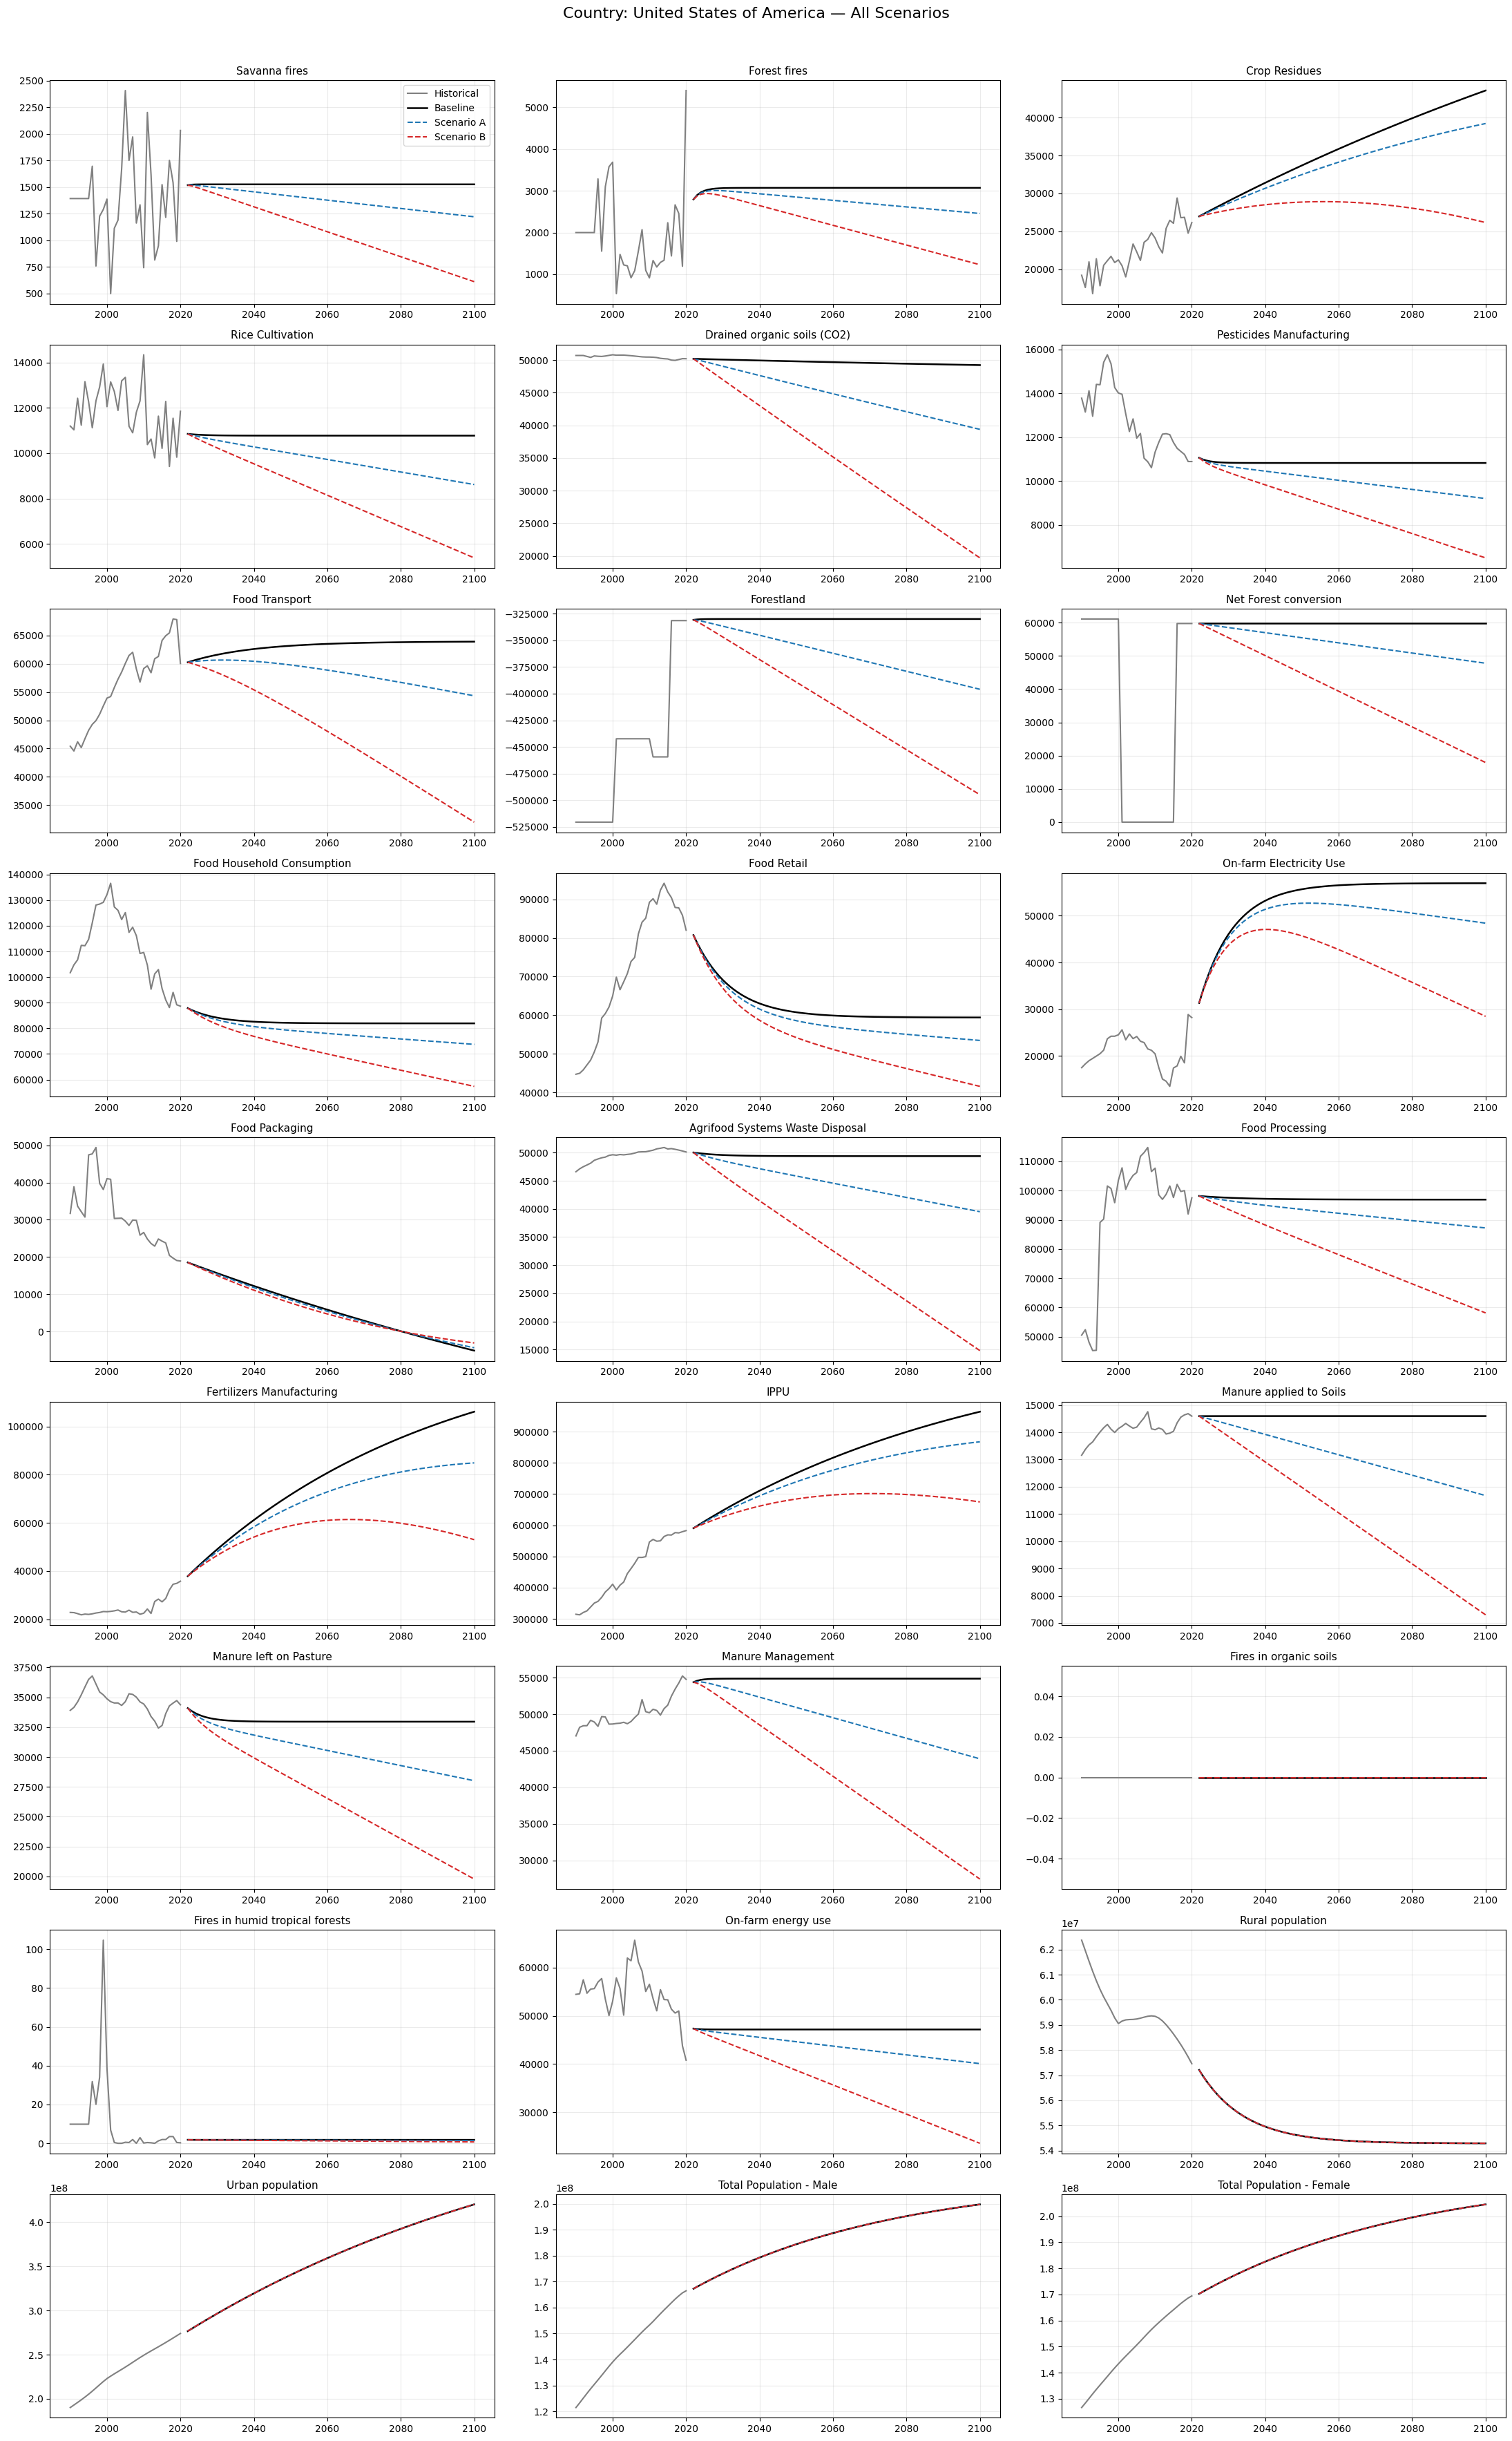

In [12]:
# sample
# sample_country = df["Area"].unique()[0]  # or "China", "India", etc.
sample_country = "United States of America"
plot_country_scenarios_all_vars(df, future_scenarios_country, sample_country, forecast_cols)

In [13]:
def plot_global_scenarios_all_vars(annual_df, df_scenarios_sum, feature_cols):
    """
    annual_df: global historical annual sums (index = datetime Year)
    df_scenarios_sum: future_scenarios_sum
    """

    # historical (already global)
    hist = annual_df.copy()
    hist["Date"] = hist.index

    # future: split scenarios
    fut_base = df_scenarios_sum[df_scenarios_sum["scenario"] == "Baseline"].copy()
    fut_A    = df_scenarios_sum[df_scenarios_sum["scenario"] == "A"].copy()
    fut_B    = df_scenarios_sum[df_scenarios_sum["scenario"] == "B"].copy()

    for f in (fut_base, fut_A, fut_B):
        f["Date"] = pd.to_datetime(f["Date"])

    cols = 3
    rows = math.ceil(len(feature_cols) / cols)

    plt.figure(figsize=(22, rows * 4))
    plt.suptitle("Global sum — All Scenarios", fontsize=16)

    for i, feature in enumerate(feature_cols, 1):
        plt.subplot(rows, cols, i)

        if feature in hist.columns:
            plt.plot(hist["Date"], hist[feature], color="gray", linewidth=1.5, label="Historical")

        plt.plot(fut_base["Date"], fut_base[feature], color="black", linewidth=1.8, label="Baseline")
        plt.plot(fut_A["Date"], fut_A[feature], linestyle="--", color="tab:blue", linewidth=1.5, label="Scenario A")
        plt.plot(fut_B["Date"], fut_B[feature], linestyle="--", color="tab:red", linewidth=1.5, label="Scenario B")

        plt.title(feature, fontsize=11)
        plt.grid(True, alpha=0.25)

        if i == 1:
            plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

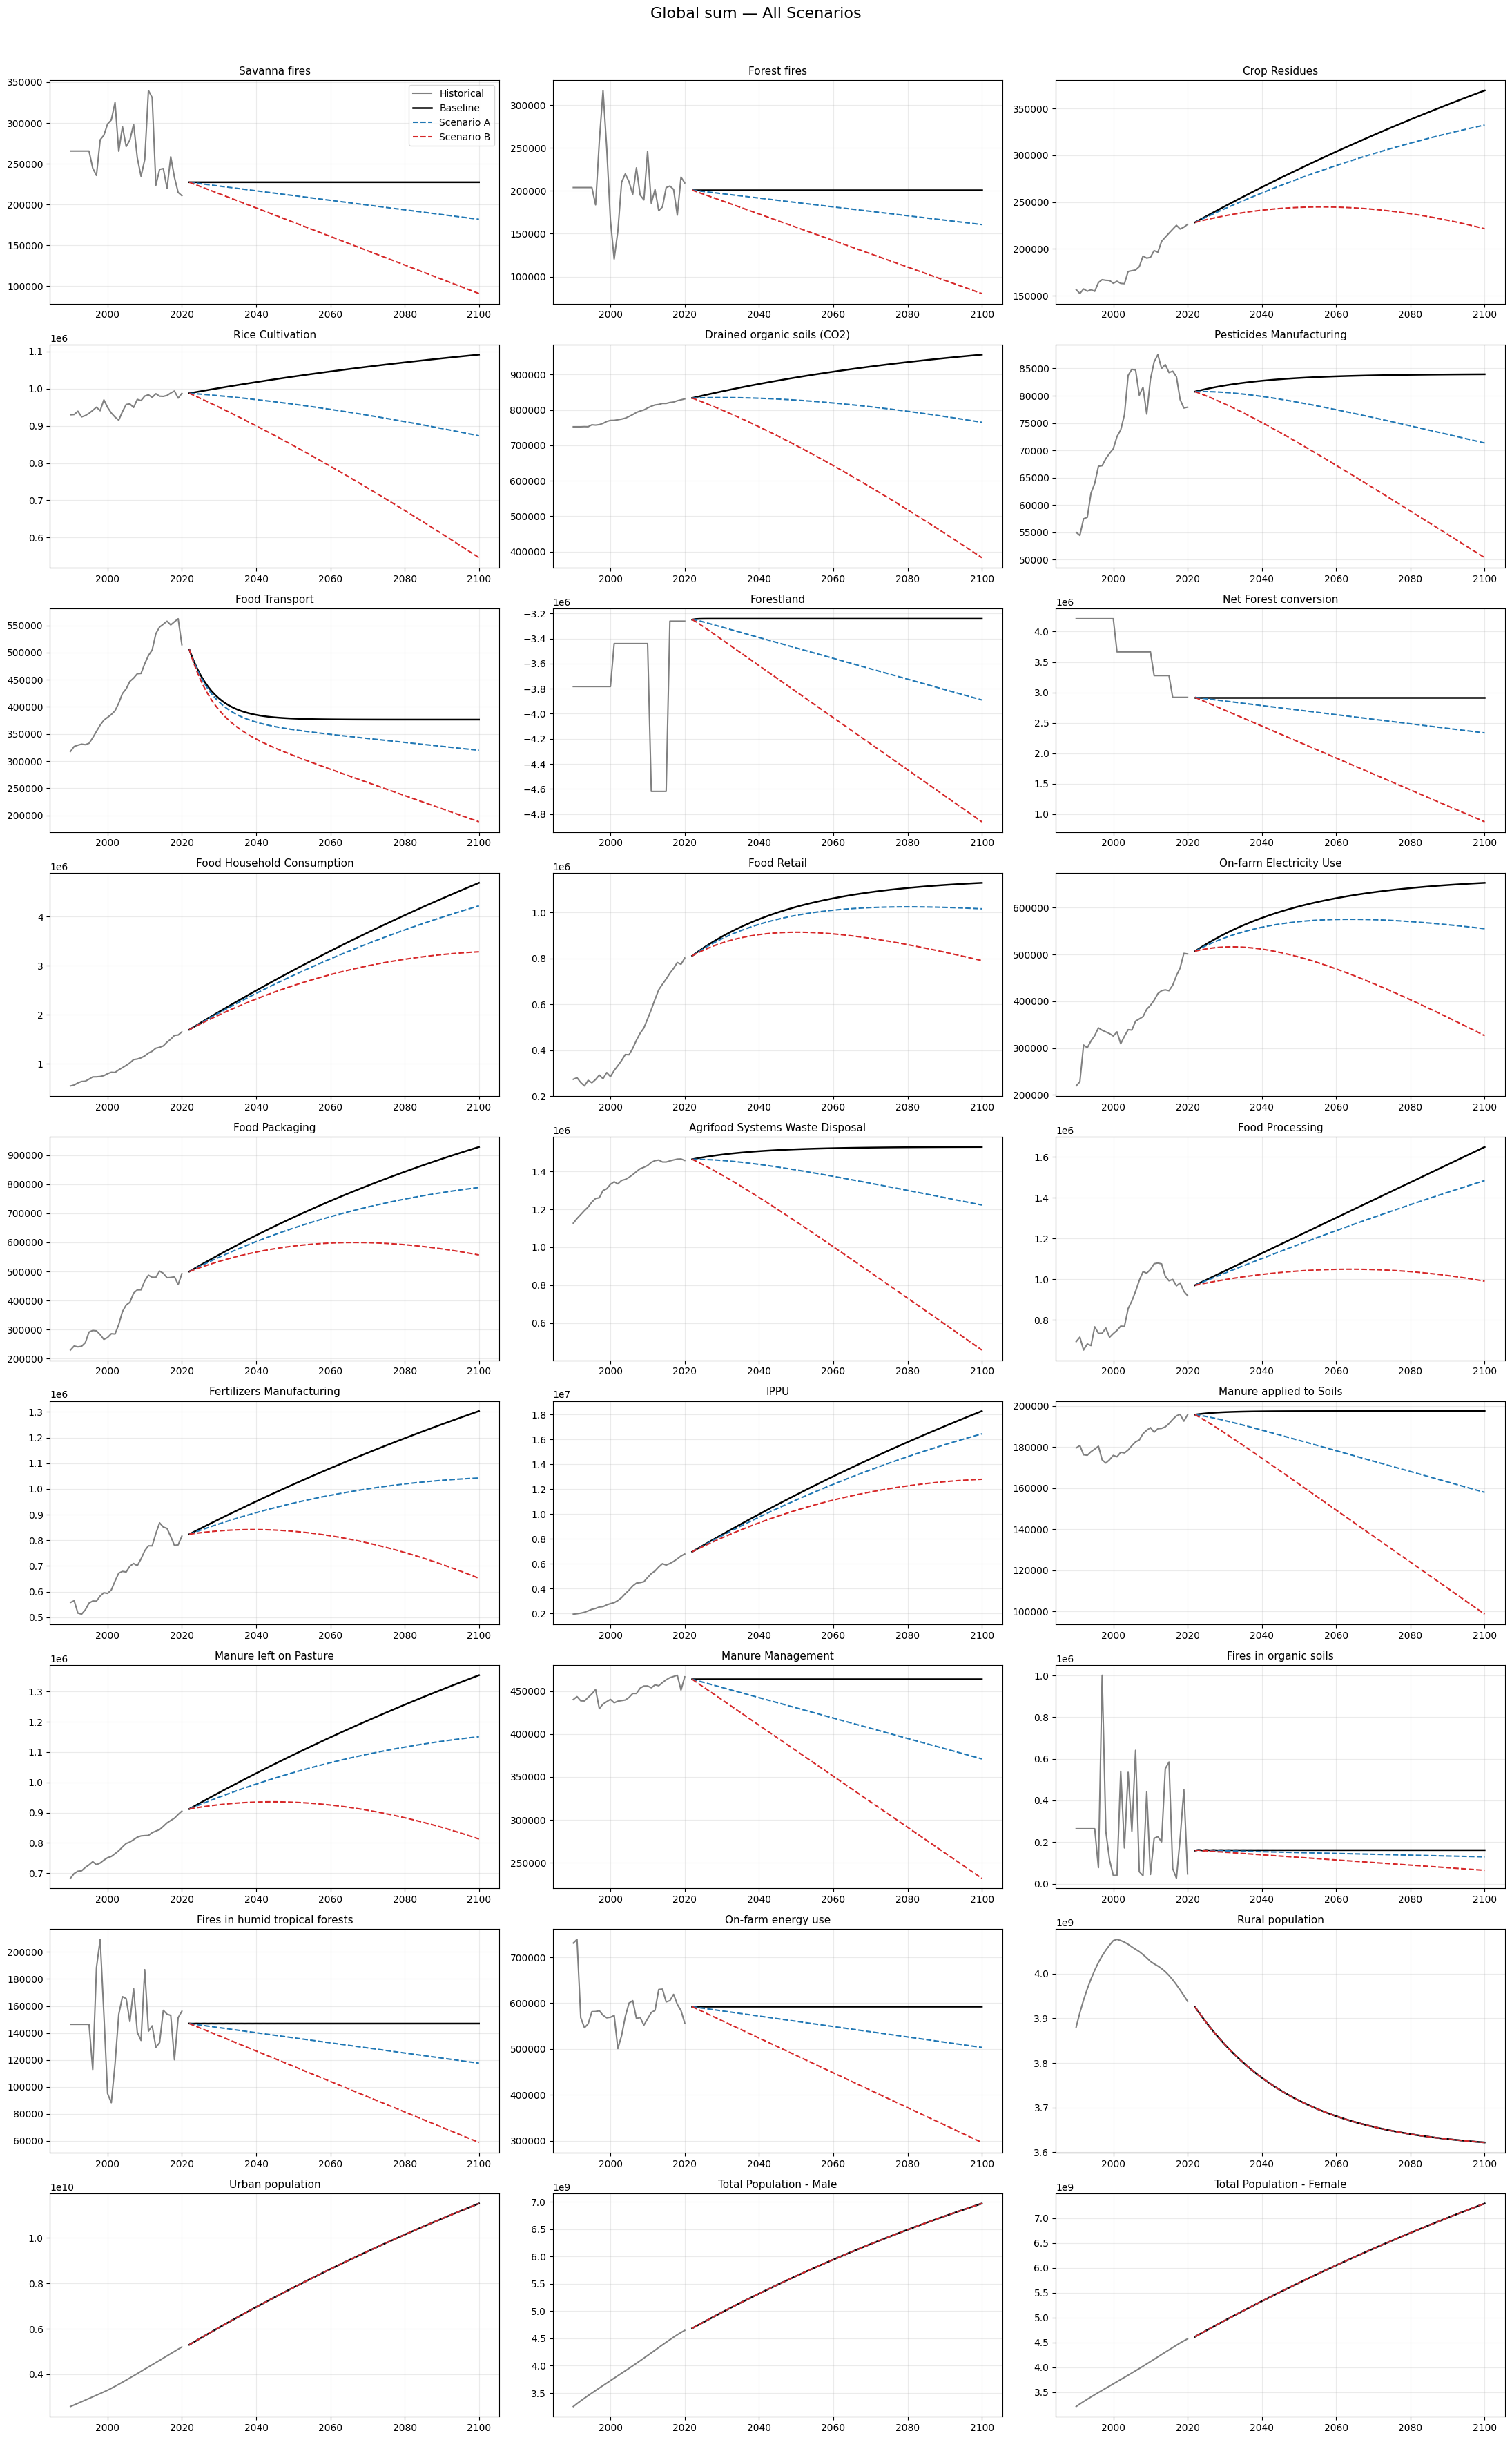

In [14]:
# sample
plot_global_scenarios_all_vars(annual_df, future_scenarios_sum, forecast_cols)

In [15]:
# ===========================
# SAVE OUTPUT DATASETS
# ===========================

# 1. Global sum scenarios
future_scenarios_sum.to_csv(
    "future_scenarios_sum.csv",
    index=False
)
print("Saved: future_scenarios_sum.csv")

# 2. Country-level scenarios
future_scenarios_country.to_csv(
    "future_scenarios_country.csv",
    index=False
)
print("Saved: future_scenarios_country.csv")


Saved: future_scenarios_sum.csv
Saved: future_scenarios_country.csv


In [16]:
# ORIGINAL dataset variables (excluding metadata columns)
ignore_cols = ["Area", "Year"]
raw_feature_cols = [
    col for col in df.columns
    if col not in ignore_cols and df[col].dtype != "object"
]

print("Raw original variables:", raw_feature_cols)


Raw original variables: ['Savanna fires', 'Forest fires', 'Crop Residues', 'Rice Cultivation', 'Drained organic soils (CO2)', 'Pesticides Manufacturing', 'Food Transport', 'Forestland', 'Net Forest conversion', 'Food Household Consumption', 'Food Retail', 'On-farm Electricity Use', 'Food Packaging', 'Agrifood Systems Waste Disposal', 'Food Processing', 'Fertilizers Manufacturing', 'IPPU', 'Manure applied to Soils', 'Manure left on Pasture', 'Manure Management', 'Fires in organic soils', 'Fires in humid tropical forests', 'On-farm energy use', 'Rural population', 'Urban population', 'Total Population - Male', 'Total Population - Female', 'total_emission', 'Average Temperature °C']


In [17]:
def plot_original_global(df, feature_cols):
    hist = df.groupby("Year")[feature_cols].sum().sort_index()
    hist.index = pd.to_datetime(hist.index.astype(str), format="%Y")
    hist["Date"] = hist.index

    cols = 3
    rows = math.ceil(len(feature_cols) / cols)

    plt.figure(figsize=(22, rows * 4))
    plt.suptitle("Original Historical Dataset (Global Sum)", fontsize=16)

    for i, feature in enumerate(feature_cols, 1):
        plt.subplot(rows, cols, i)
        plt.plot(hist["Date"], hist[feature], color="black", linewidth=1.6)
        plt.title(feature, fontsize=11)
        plt.grid(True, alpha=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


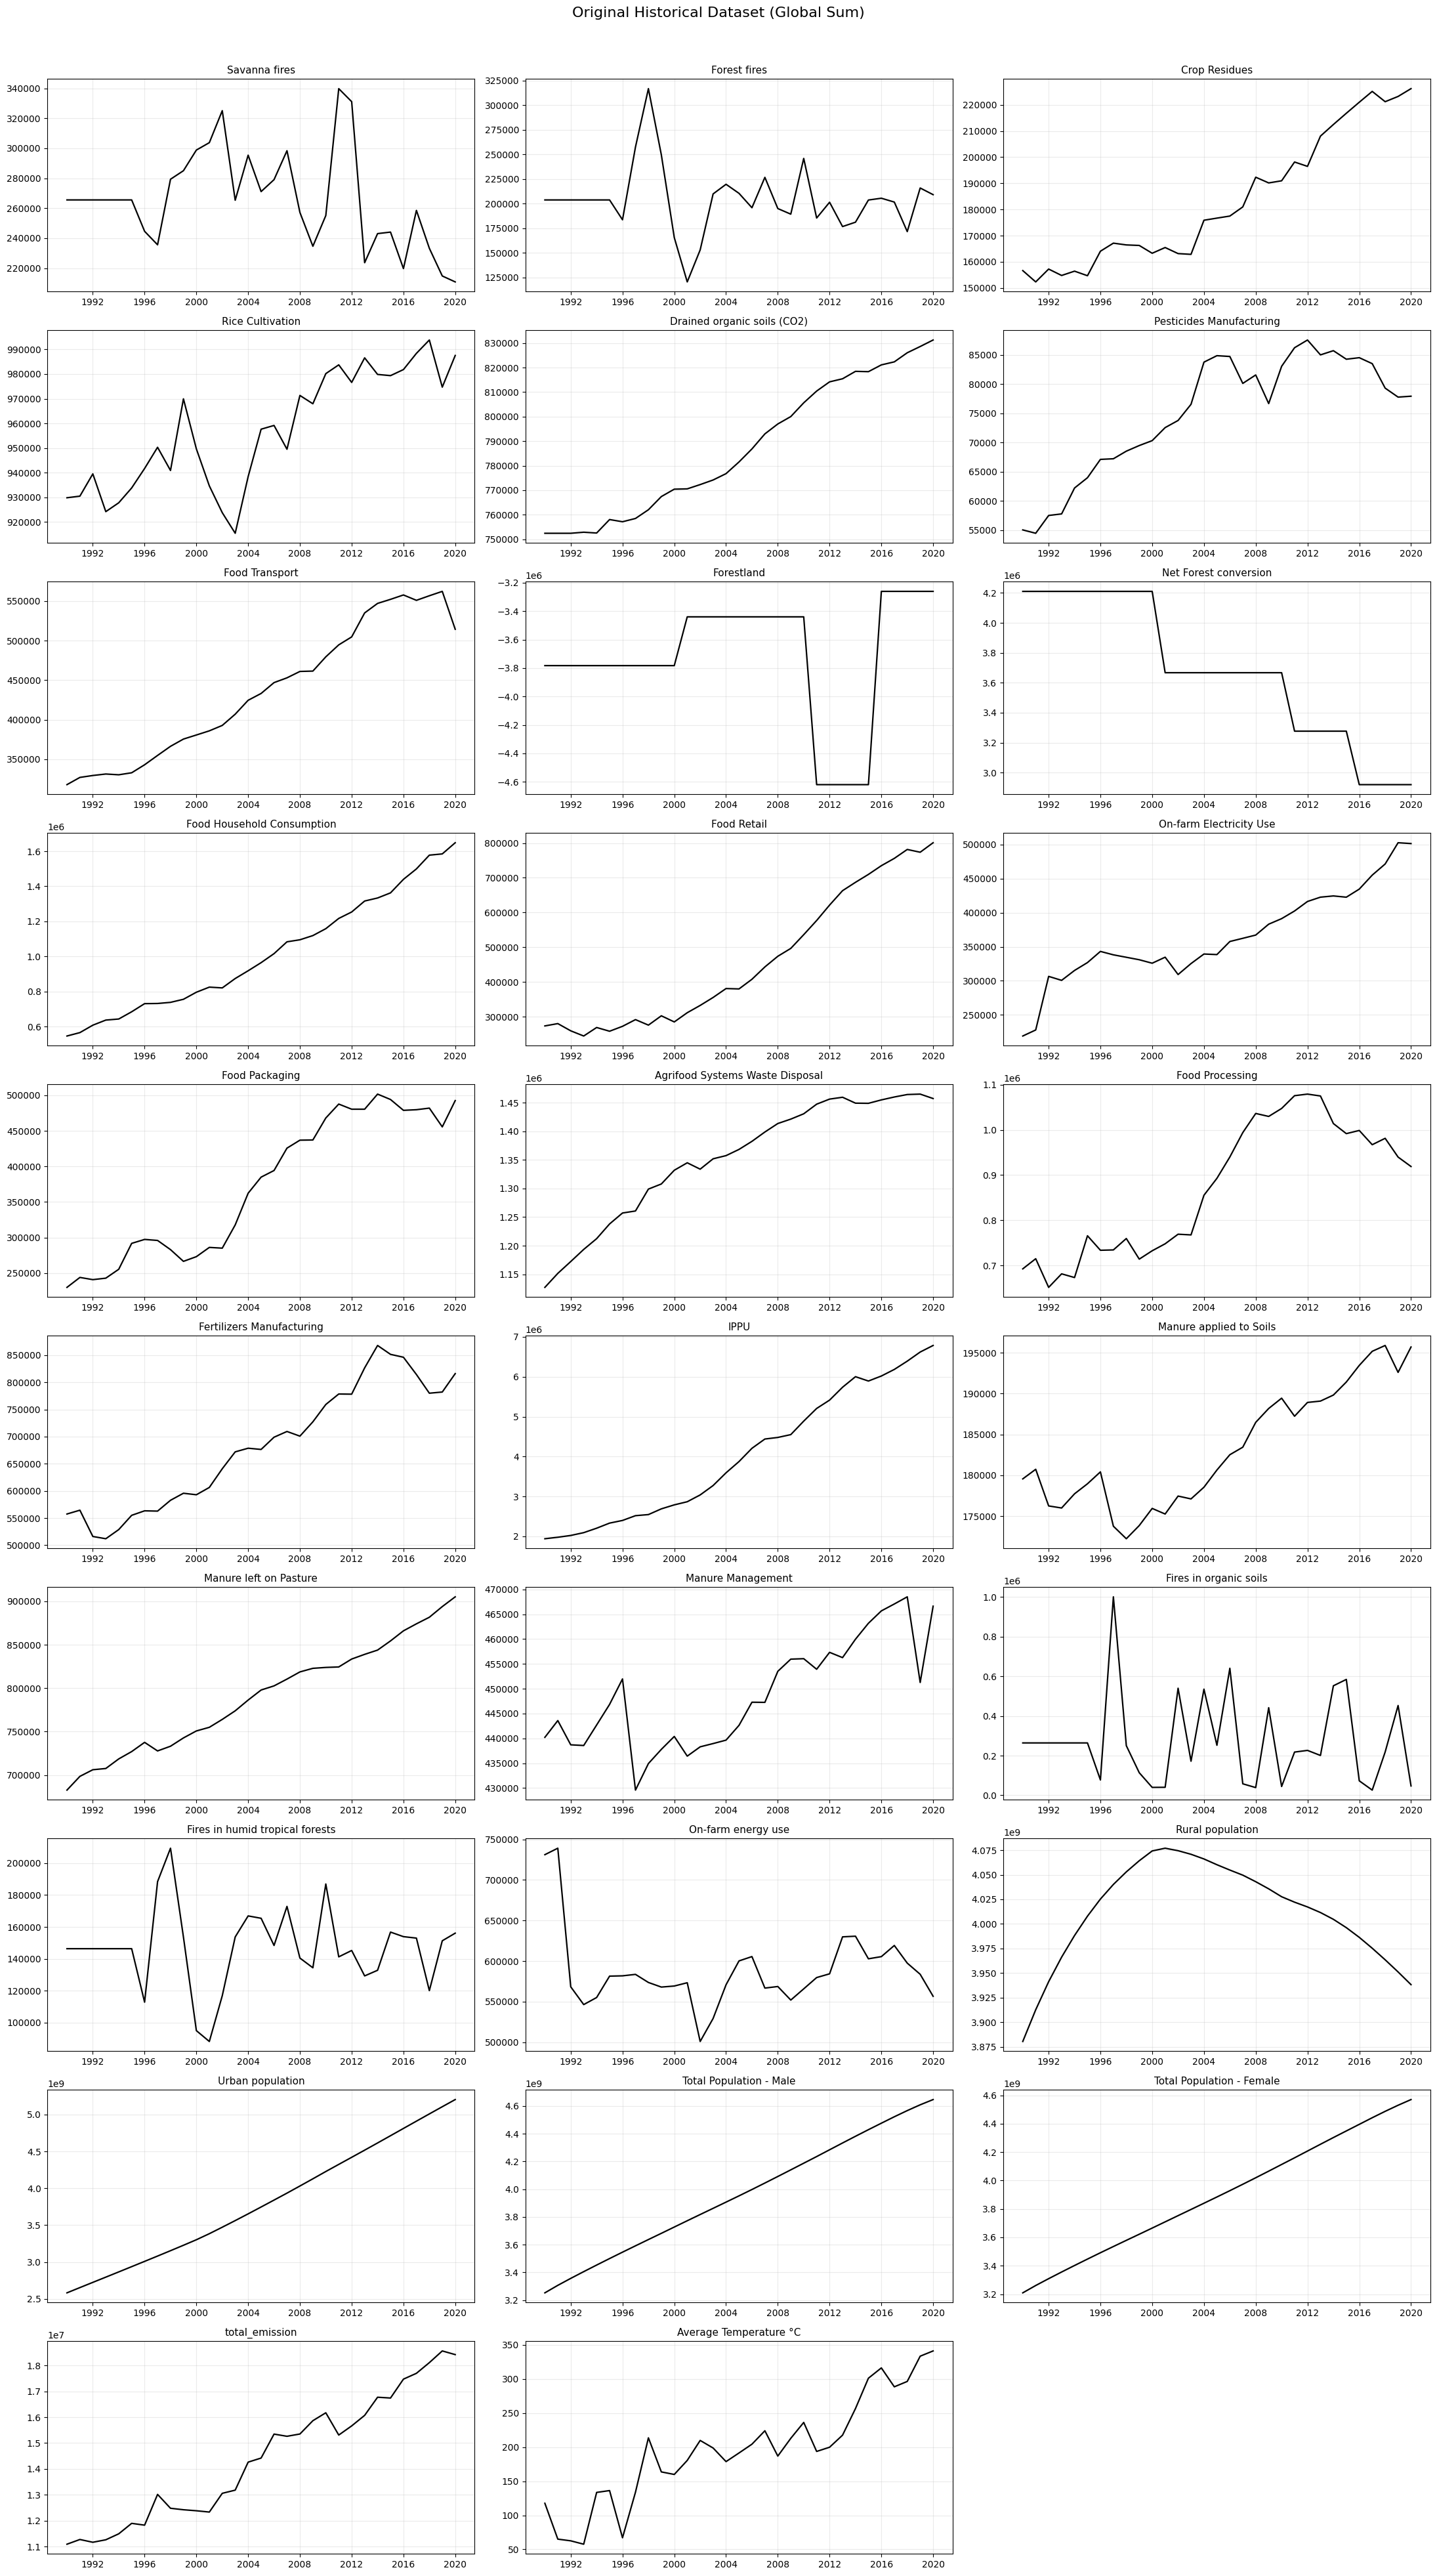

In [18]:
plot_original_global(df, raw_feature_cols)
